## Постановка задачи

На первой практике вам предстоит поработать с реальными данными об истории экспертиз рабочих программ дисциплин в ИТМО.

**Задача:** сделать краткое исследование данных и построить 3 графика двумя способами. Первый способ - самостоятельно. Второй - с активной помощью ChatGPT, Perplexity или [любого другого ИИ](https://theresanaiforthat.com/). Порядок реализации способов значения не имеет. Библиотеки можно использовать любые.

**Цель:** оценить качество помощи ИИ для аналитики. В конце обязательно сделайте текстовый вывод по результатам работы!

## Загрузка данных

Загрузим датасет в колаб, найти его также можно [по ссылке](https://drive.google.com/file/d/1mJoAbyxf7vUU8_bVQvsahdW3HY8uz-V8/view?usp=share_link), если по какой-то причине у вас не работает gdown.

In [1]:
import pandas as pd

!gdown 1mJoAbyxf7vUU8_bVQvsahdW3HY8uz-V8

Downloading...
From: https://drive.google.com/uc?id=1mJoAbyxf7vUU8_bVQvsahdW3HY8uz-V8
To: /content/exp_stats.csv
100% 925k/925k [00:00<00:00, 18.9MB/s]


Посмотрим на данные.

In [33]:
data = pd.read_csv("/content/exp_stats.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7657 entries, 0 to 7656
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   workprogram_id     7657 non-null   int64 
 1   user_count         7657 non-null   int64 
 2   expertise_status   7657 non-null   object
 3   expertise_counter  7657 non-null   int64 
 4   approval_date_y    7657 non-null   object
 5   title              7657 non-null   object
dtypes: int64(3), object(3)
memory usage: 359.1+ KB


Всего шесть столбцов, все без пропусков:
- `workprogram_id` - айди рабочей программы (РПД)
- `user_count` - сколько человек принимали участие в создании РПД
- `expertise_status` - на каком этапе экспертизы находится РПД (статус экспертизы: AC - одобрена, RE - на доработке, AR - в архиве, EX - на экспертизе, WK - в работе)
- `expertise_counter` - сколько раз РПД проходила экспертизу
- `approval_date` - день, когда РПД признали удовлетворяющей всем требованиям и разрешили ее реализовывать
- `title` - название дисциплины


In [3]:
data.head()

,workprogram_id,user_count,expertise_status,expertise_counter,approval_date_y,title
0,2626,4,AC,1,2022-05-06 14:23:17.924 +0200,Философия
1,8461,4,AC,1,2022-04-28 09:01:59.171 +0200,Философия
2,2627,3,AC,5,2021-08-31 20:51:19.142 +0200,Введение в цифровую культуру и программирование
3,2628,4,AC,0,2022-04-28 11:36:30.474 +0200,Проектирование баз данных
4,2631,4,AC,0,2022-04-28 12:06:31.165 +0200,Современные вопросы информатики


## Краткое исследование данных

В данных не слишком много столбцов и уже известно, что нет пустых ячеек. Теперь неплохо было бы погрузиться в них и ответить на 3 небольших вопроса:
1. Какой период охватывают данные в датасете?
2. Есть ли в данных нетипичные значения? Например, неположительные числа в столбце `user_count`. Или даты, которые сильно выбиваются из общего диапазона значений.
3. Есть ли нелогичные значения в данных? Например, статус РПД "в работе", но есть `approval_date`. Или статус "одоберно", но РПД 0 раз проходила экспертизу.



In [4]:
data["approval_date_y"] = pd.to_datetime(data["approval_date_y"], errors="coerce")
date_range = (data["approval_date_y"].min(), data["approval_date_y"].max())
date_range

<ipython-input-4-7a735e5b6c11>:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  data["approval_date_y"] = pd.to_datetime(data["approval_date_y"], errors="coerce")


(Timestamp('2021-04-21 11:32:30.614000+0200', tz='UTC+02:00'),
 Timestamp('2023-04-17 11:35:20.872000+0200', tz='UTC+02:00'))

In [38]:
invalid_user_count = data[data["user_count"] <= 0]
invalid_user_count

,workprogram_id,user_count,expertise_status,expertise_counter,approval_date_y,title


In [37]:
data["approval_date_y"] = pd.to_datetime(data["approval_date_y"], errors="coerce")
date_outliers = data[~data["approval_date_y"].between(date_range[0], date_range[1])]
date_outliers

,workprogram_id,user_count,expertise_status,expertise_counter,approval_date_y,title
5,20745,2,AC,1,NaT,Современные вопросы теоретической информатики
9,14593,2,AC,1,NaT,Иностранный язык
17,2646,4,AC,1,NaT,Современные инструменты анализа данных
22,22808,2,AC,0,NaT,Линейная алгебра
25,22831,3,AC,3,NaT,Дискретная математика
...,...,...,...,...,...,...
7639,24553,3,RE,0,NaT,История и актуальные стратегии art&science / H...
7641,24572,1,AC,0,NaT,Изменение климата: адаптация и последствия
7644,24619,4,EX,1,NaT,Испанский язык 2
7645,24623,1,AC,0,NaT,Основы термодинамики экологических систем


In [7]:
invalid_approval_status = data[
    (data["expertise_status"].isin(["WK", "EX", "RE"])) & data["approval_date_y"].notna()
]
invalid_expertise_count = data[(data["expertise_status"] == "AC") & (data["expertise_counter"] == 0)]
invalid_expertise_count

,workprogram_id,user_count,expertise_status,expertise_counter,approval_date_y,title
3,2628,4,AC,0,2022-04-28 11:36:30.474000+02:00,Проектирование баз данных
4,2631,4,AC,0,2022-04-28 12:06:31.165000+02:00,Современные вопросы информатики
18,19151,10,AC,0,2022-10-07 19:07:20.602000+02:00,Современные инструменты анализа данных
22,22808,2,AC,0,2023-01-30 12:41:48.484000+01:00,Линейная алгебра
23,2654,7,AC,0,2021-07-08 16:06:24.358000+02:00,Дискретная математика
...,...,...,...,...,...,...
7650,24945,4,AC,0,2023-04-02 00:25:17.606000+02:00,Математические модели низкоразмерных систем
7651,24946,4,AC,0,2023-04-02 00:25:29.275000+02:00,Методы моделирования многочастичных систем
7652,24947,4,AC,0,2023-04-02 00:23:26.939000+02:00,Методы моделирования прикладных физических задач
7655,24983,4,AC,0,2023-04-02 00:52:24.479000+02:00,Теория вероятностей


Теперь ответьте на более интересные вопросы с использованием визуализаций.

Заранее уберу строки без даты

In [23]:
data = data[data["approval_date_y"].between(date_range[0], date_range[1])]

### 1. Как распределяется количество редакторов рабочих программ на всем периоде наблюдений?

Мой график:

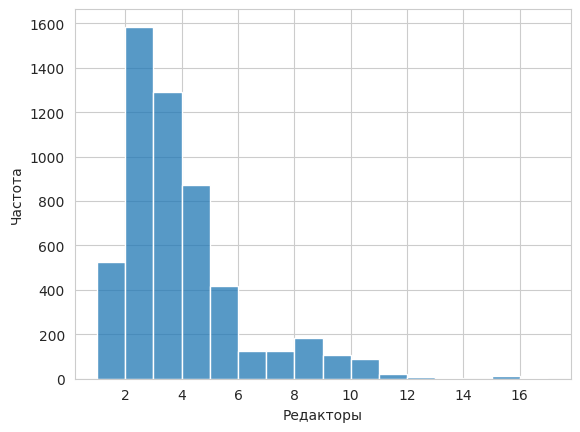

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib

sns.histplot(data=data, x='user_count',binwidth=1)
sns.set_style('whitegrid')

plt.xlabel("Редакторы")
plt.ylabel("Частота")
plt.show()

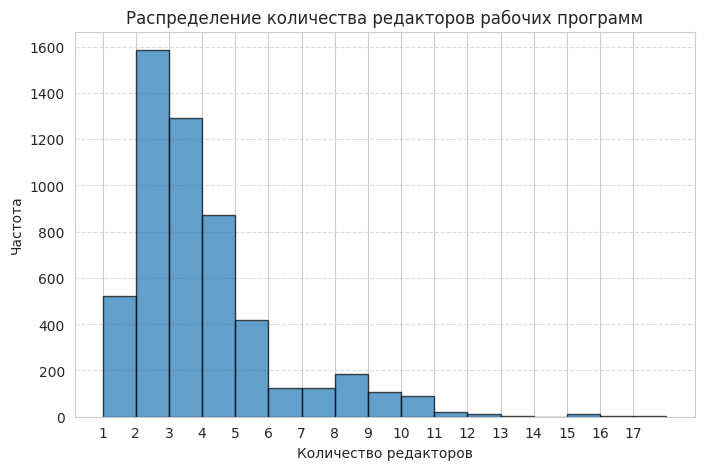

In [25]:
import matplotlib.pyplot as plt

# Построим гистограмму количества редакторов
plt.figure(figsize=(8, 5))
plt.hist(data["user_count"], bins=range(data["user_count"].min(), data["user_count"].max() + 2), edgecolor="black", alpha=0.7)
plt.xlabel("Количество редакторов")
plt.ylabel("Частота")
plt.title("Распределение количества редакторов рабочих программ")
plt.xticks(range(data["user_count"].min(), data["user_count"].max() + 1))
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

### 2. Как со временем менялось среднее количество экспертиз РПД?

Мой график:

<ipython-input-29-580c2a3443c6>:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  data["approval_month"] = data["approval_date_y"].dt.to_period("M").astype(str)


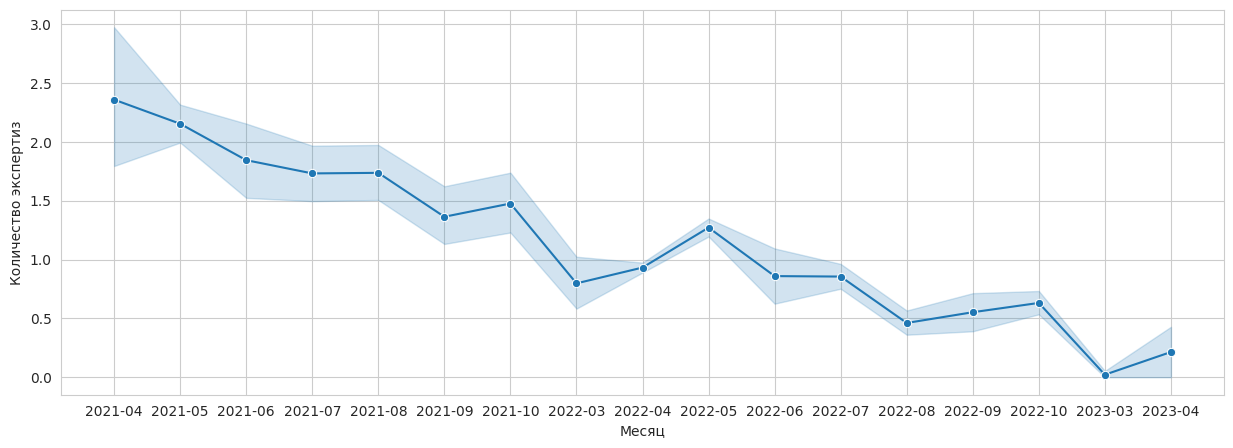

In [29]:
data["approval_date_y"] = pd.to_datetime(data["approval_date_y"], errors="coerce")
data["approval_month"] = data["approval_date_y"].dt.to_period("M").astype(str)
data = data.sort_values("approval_month")



plt.figure(figsize=(15, 5))

sns.lineplot(data=data, x="approval_month", y="expertise_counter", marker="o")
plt.xlabel("Месяц")
plt.ylabel("Количество экспертиз")
plt.show()

ChatGPT:

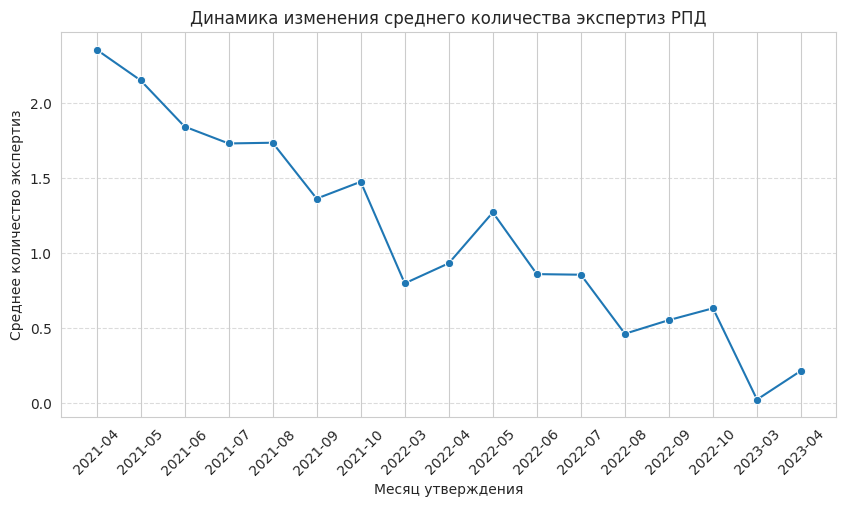

In [27]:
import seaborn as sns
# Группируем данные по году и месяцу, считаем среднее количество экспертиз
expertise_trend = data.groupby("approval_month")["expertise_counter"].mean().reset_index()

expertise_trend = data.groupby("approval_month")["expertise_counter"].mean().reset_index()
expertise_trend = expertise_trend.sort_values("approval_month")

# Визуализация
plt.figure(figsize=(10, 5))
sns.lineplot(data=expertise_trend, x="approval_month", y="expertise_counter", marker="o")

plt.xlabel("Месяц утверждения")
plt.ylabel("Среднее количество экспертиз")
plt.title("Динамика изменения среднего количества экспертиз РПД")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

### 3. Есть ли зависимость между датой и присвоением статуса "одобрено" (AC)?

Мой график:

<ipython-input-20-f0efabd2fff4>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="approval_month", y="count", palette="Blues_d")


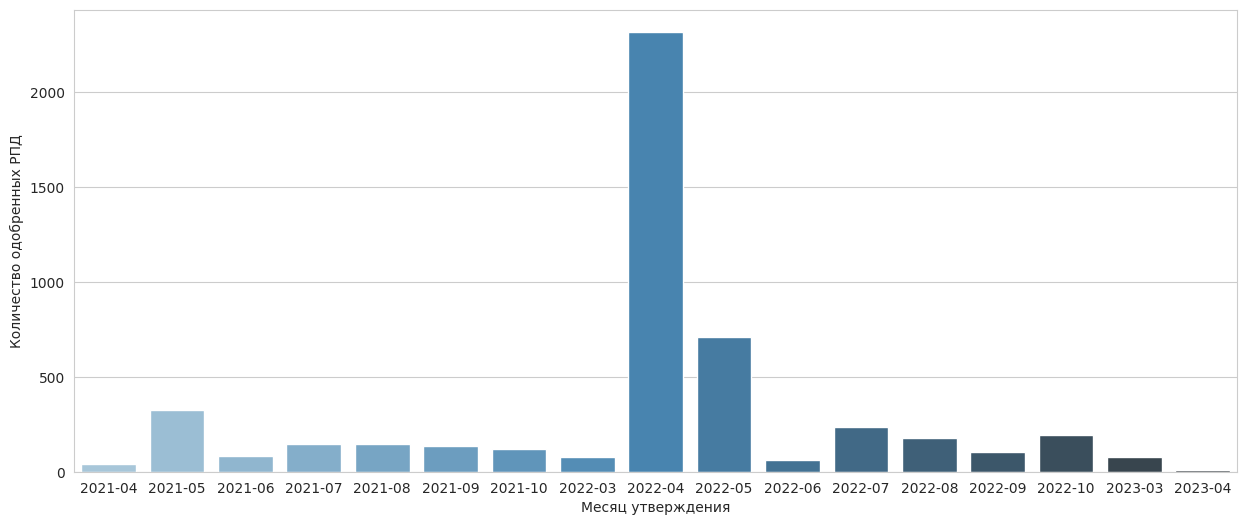

In [20]:
df = data[data['expertise_status'] == 'AC'].groupby('approval_month').size().reset_index(name='count')

plt.figure(figsize=(15, 6))
sns.barplot(data=df, x="approval_month", y="count", palette="Blues_d")

plt.xlabel("Месяц утверждения")
plt.ylabel("Количество одобренных РПД")
plt.show()

ChatGPT:

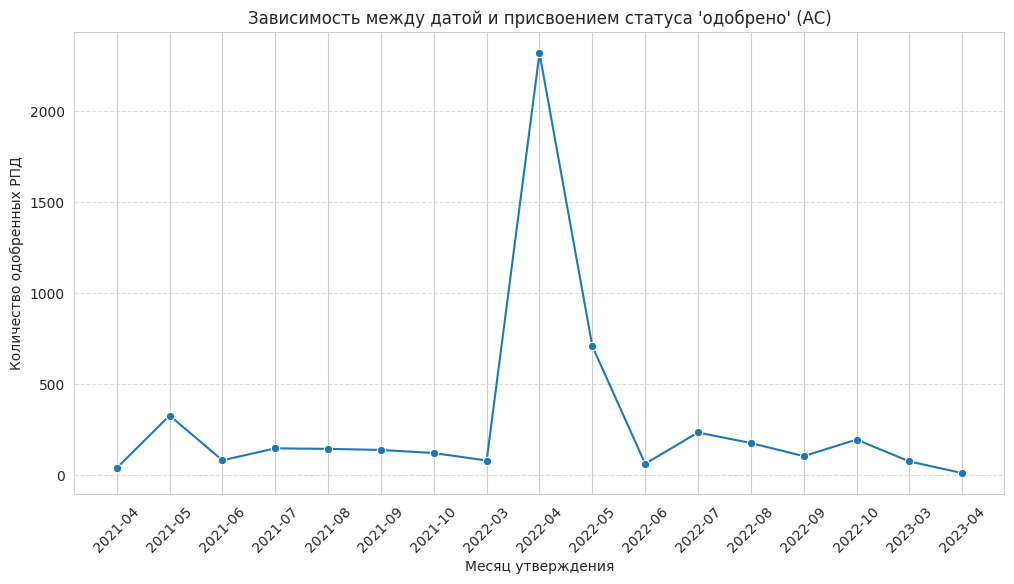

In [21]:
# Фильтруем данные для статуса "AC"
ac_data = data[data["expertise_status"] == "AC"]

# Группируем данные по месяцу и подсчитываем количество
ac_trend = ac_data.groupby("approval_month").size().reset_index(name="count")

# Визуализация
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.lineplot(data=ac_trend, x="approval_month", y="count", marker="o")

plt.xlabel("Месяц утверждения")
plt.ylabel("Количество одобренных РПД")
plt.title("Зависимость между датой и присвоением статуса 'одобрено' (AC)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

### Оцените результаты

Графики полученные чатом GPT не сильно визуально отличаются от моих, но выглядят аккуратнее, т.к. я не всегда подписываю графики или не знаю каких-то возможностей библиотеки для визуализации.


В целом использование ИИ в визуализации позволяет ускорить работу. ИИ часто справляется лучше человека в визуализации, но получается это только если подобно составить запрос (часто не с первого раза, надо сделать еще пару уточнаящих комментариев или исправить ошибки например). Если данные тяжело анализировать или график является нестандартным, то работа затрудняется и время затраченное на визуализацию сильно увеличивается (если работа вообще представляется возможной). Но с простыми графиками справляется хорошо.